In [1]:
#FULL DOMAIN RUN

# code for tracing particles back to SBZ draft (python version 3.10.9) (not optimized with numpy.where)
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import os; import time

start_time = time.time();

#data loading
################################################################################################################################################################################################################
dir='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
data=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_test7tundra-7_062217.nc') #***
times=data['time'].values/(1e9 * 60); times=times.astype(float);
minutes=1/times[1] #1 / minutes per timestep = timesteps per minute
parcel=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_pdata_test5tundra-7_062217.nc') #***
kms=np.argmax(data['xh'].values-data['xh'][0].values >= 1)
res='1km'

#LOADING CL MAXS FROM CL TRACKING ALGORITHM
dir='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
whereCL=xr.open_dataset(dir+'Project_Algorithms/whereCL_4_0622.nc').load()
whereCL=whereCL.isel(time=slice(0,len(data['time'])))
whereCL=whereCL['maxconv_x']
def Get_Conv_X(t,z,y):
    Conv_X_Max=whereCL[t,z,y,:].values
    return Conv_X_Max

index_adjust=0

In [53]:
#job array things
################################################################################################################################################################################################################
num_jobs=60 #how many total jobs are being run? i.e. array=1-100 ==> num_jobs=100 #***

job_id = int(os.environ.get('SLURM_ARRAY_TASK_ID', 0)) #this is the current SBATCH job id
if job_id==0: job_id=1
num_parcels=len(parcel['xh']) #total number of parcels
job_range = num_parcels//num_jobs #number of parcels per job 

# Calculate start and end based on job_id
start_job = (job_id - 1) * job_range
end_job = start_job + job_range
if job_id==num_jobs: end_job=num_parcels
print(f'running for parcels {start_job}-{end_job-1}')
parcel=parcel.isel(xh=slice(start_job,end_job)) #slices the lagrangian parcel data
index_adjust=parcel['xh'].values.astype(int)[0]-1 #for correction of parcel index name



running for parcels 2083-4165


In [54]:
# # Reading Back Data Later
# ##############
# import h5py
# dir2=dir+'Project_Algorithms/Lagrangian_Binary_Array/'
# with h5py.File(dir2+'lagrangian_binary_array.h5', 'r') as f:
#     # Load the dataset by its name
#     # A_g = f['A_g'][:]
#     # A_c = f['A_c'][:]

#     W = f['W'][:]
#     # QCQI = f['QCQI'][:]
#     Z = f['Z'][:]
#     Y = f['Y'][:]
#     X = f['X'][:]

# # #Making Time Matrix
# # rows, cols = A.shape[0], A.shape[1]
# # T = np.arange(rows).reshape(-1, 1) * np.ones((1, cols), dtype=int)

# Reading Back Data Later
##############
import h5py
dir2=dir+'Project_Algorithms/Lagrangian_Binary_Array/'
with h5py.File(dir2+'lagrangian_binary_array.h5', 'r') as f:
    # Load the dataset by its name

    W = f['W'][:,start_job:end_job]
    Z = f['Z'][:,start_job:end_job]
    Y = f['Y'][:,start_job:end_job]
    X = f['X'][:,start_job:end_job]

In [55]:
# # Reading Back Data Later
# ##############
# import h5py
# dir2=dir+'Project_Algorithms/Lagrangian_Binary_Array/'
# with h5py.File(dir2+f'LFC_LCL_binary_array.h5', 'r') as f:
#     # Load the dataset by its name
#     LFC = f['LFC'][:]
#     LCL = f['LCL'][:]

# Reading Back Data Later
##############
import h5py
dir2=dir+'Project_Algorithms/Lagrangian_Binary_Array/'
with h5py.File(dir2+f'LFC_LCL_binary_array.h5', 'r') as f:
    # Load the dataset by its name
    LFC = f['LFC'][:,start_job:end_job]
    LCL = f['LCL'][:,start_job:end_job]

In [63]:
# #TESTING TESTING TESTING****
# #out_arr

# # out=xr.open_dataset(dir+'tracking_algorithms/trackout/parcel_tracking_everywhere_OLD.nc')['out_arr'].values;out=out.astype(object);out[:, [0,1,2,4,5]] = out[:, [0,1,2,4,5]].astype(int) #***
# # save=xr.open_dataset(dir+'tracking_algorithms/trackout/parcel_tracking_everywhere_OLD.nc')['save_arr'].values;save=save.astype(object);save[:, [0,1,2,4,5]] = save[:, [0,1,2,4,5]].astype(int) #***


# out=xr.open_dataset(dir+'Project_Algorithms/Tracking_Algorithms/trackout/parcel_tracking_combined.nc')['out_arr'].values;out=out.astype(object);out[:, [0,1,2,4,5]] = out[:, [0,1,2,4,5]].astype(int) #***
# save=xr.open_dataset(dir+'Project_Algorithms/Tracking_Algorithms/trackout/parcel_tracking_combined.nc')['save_arr'].values;save=save.astype(object);save[:, [0,1,2,4,5]] = save[:, [0,1,2,4,5]].astype(int) #***

# out_arr=out[~np.all(out == 0, axis=1)];#print('list of first 10 SBZ parcels'); print(out_arr[:15])
# save_arr=save[~np.all(save == 0, axis=1)];save_arr=save_arr[np.where(np.unique(save_arr[1:-1,0]))];#print('list of first 10 ignored parcels');print(save_arr[:5])

# ###############################################################################
# #remove duplicates
# lst=[]
# unique_values, counts = np.unique(out_arr[:,0], return_counts=True); duplicates = unique_values[counts > 1]
# for elem in duplicates:
#     idx = np.where(out_arr[:,0] == elem)[0] 
#     extras=idx[np.where(out_arr[idx,5]!=np.min(out_arr[idx,5]))]
#     lst.extend([x for x in extras])
# mask=np.ones(len(out_arr), dtype=bool); mask[lst] = False
# out_arr=out_arr[mask]; 
# ###############################################################################

# out_arr=out[~np.all(out == 0, axis=1)];print('list of first 10 SBZ parcels'); print(out_arr[:15])
# save_arr=save[~np.all(save == 0, axis=1)];save_arr=save_arr[np.where(np.unique(save_arr[1:-1,0]))];print('list of first 10 ignored parcels');print(save_arr[:5])
# placeholder=out_arr.copy(); run=True
# ############################################################
# print(f'there are a total of {len(out_arr)} CL parcels and {len(save_arr)} nonCL parcels')


# ALL_out_arr=out_arr.copy(); ALL_save_arr=save_arr.copy()

In [ ]:
#################################################################

In [521]:
#Updated Lagrangian Tracking Algorithm

#Algorithm Steps:
#(1) Find the first time a parcel is above the LFC:
#(2) First check if the parcel ascends (w>=0.1) for another 20 minutes
#(3) If so, find first time, the parcel slows down (w<0.1)
#(4) If that time is when the parcel is above 750m, save it, "forget", and move on to next parcel
#(5) If that time is when the parcel is below 750m, check if it is within 2km of the CL_Max found from the CL Tracking Algorithm
#(6) If the parcel is near the CL, store in, otherwise save it, "forget", and move on to next parcel
#(7) Continue to next parcel

#(Also, if during, traceback, the parcel escapes the x or z boundary, "forget" parcel, and move on)

In [56]:
#Numerical Settings
Nt=len(data['time'])
Np=len(parcel['xh'])
dt=times[1]*60 #300 secs

#For saving ascend-after-LFC info
ascend_lst=[]
CLmaxheight=750 #750m

#BL slow-down-threshold
w_thresh=0.1

In [57]:
# if ((x + dt*u)==0) or ((z + dt*w)==0)
# u=u[t,Z[t,p],Y[t,p],X[t,p]]; W=W[t,p]
# [u[t,Z[t,p],Y[t,p],X[t,p]] for t in time_arr] >np.max(data['xf'].values) or < np.min(data['xf'].values)
# similarly for w
################################################################################################################
#BOUNDARY-ESCAPE CONDITION
xmin=np.min(data['xf'].values)*1e3
xmax=np.max(data['xf'].values)*1e3
zmin=np.min(data['zf'].values)*1e3
zmax=np.max(data['zf'].values)*1e3

def check_boundary(p,where_BL,above_LFC):
    time_arr=np.arange(where_BL,above_LFC)

    def get_u(t,z,y,x):
        # return data['u'].isel(time=t,zh=z,yh=y).interp(xf=data['xh']).isel(xh=x).item()
        # return data['uinterp'].isel(time=t,zh=z,yh=y,uh=u).item()
        return parcel['u'][t,p].item()
    def get_x(t,p):
        return parcel['x'][t,p].item()
    def get_w(t,z,y,x):
        # return data['w'].isel(time=t,yh=y,xh=x).interp(zf=data['zh']).isel(zh=z).item()
        # return data['winterp'].isel(time=t,zh=z,yh=y,uh=u).item()
        return parcel['w'][t,p].item()
    def get_z(t,p):
        return parcel['z'][t,p].item()


    x_tend = [get_x(t, p) + dt * get_u(t, z, y, x)  
          for (t, z, y, x) in zip(time_arr, Z[time_arr, p], Y[time_arr, p], X[time_arr, p])] 
    z_tend = [get_z(t, p) + dt * get_w(t, z, y, x)  
          for (t, z, y, x) in zip(time_arr, Z[time_arr, p], Y[time_arr, p], X[time_arr, p])] 

    x_bound=any(val < xmin or val > xmax for val in x_tend)*1
    z_bound=any(val < zmin or val > zmax for val in z_tend)*1

    out=(x_bound,z_bound)
    if any(np.array(out)==1):
        print(f'parcel {p} crossed boundary between t={where_BL} and t={above_LFC}')
    return out
#############################################################################################################

In [ ]:
#############################################################################################################
#The Algorithm

In [58]:
#Initialize Output Storage Vector

#int 32 can store up to the number 2,147,483,647 
#int 32 has 4 bytes per number, so needs (Np*3)*4 bytes of memory
#Np=125000 ==> (125000*3*4)/(1024**3) = 0.001 GB
#Np=50e6 ==> (50e6*3*4)/(1024**3) = 0.56 GB

out_arr=np.zeros((Np,3)) 
save_arr=np.zeros((Np,3)) #This one is for saving continued-ascent, slow-below-750m parcels that are not with 2 km of CL
save2_arr=np.zeros((Np,3)) #This one is for saving continued-ascent, slow-above-750m parcels

In [643]:
# i=-1

In [59]:
#1--------------Looping over each parcel

# i+=1
# test=0;test_p=ALL_out_arr[:,0][i] #TESTING***
# for count,p in enumerate([test_p]): #TESTING***

# test=0;test_p=ALL_out_arr[:,0]
# for count,p in enumerate(test_p.astype(int)): #TESTING***
for count,p in enumerate(np.arange(Np)): #TESTING***

    if np.mod(p,1e4)==0: print(f'current parcel: {p}/{Np}')
    
    W_p = W[:,p]
    LFC_p = LFC[:,p] 
   
    #----FIND WHERE PARCEL IS ABOVE LFC----
    indices = np.where(LFC_p == 1)[0]; above_LFC = indices[0] if indices.size > 0 else -999; #FIRST TIME ABOVE LFC
    if above_LFC ==-999:
        print(f'parcel {p} never above LFC')
        continue #if the parcel is never above the LFC, skip the parcel
    
    #----CHECK IF ASCENDS FOR >= 20 minutes AFTER LFC----
    ascend_array=W_p[above_LFC+1:]
    indices=np.where(ascend_array==0)[0]; ascend_stop=indices[0] if indices.size > 0 else 10000; #location of where parcel stops ascending (labeled 10000 to mark for future analysis)
    ascend_lst.append(ascend_stop) #(also store for histogram)
    if ascend_stop>=20*minutes:
    
        #----FIND THE FIRST TIME W_p<=w_thresh----
        indices=np.where(W_p[0:above_LFC]<w_thresh)[0]
        where_BL=indices[-1] if indices.size > 0 else -999 #FIRST PRIOR TIME W<0.1 (IN THE BL) (ADDED 1 TO GET TIME RIGHT AFTER INTERACTION)
        if where_BL ==-999:
            print(f'parcel {p} w is never below threshold prior to t={above_LFC}')
            continue #if the parcel never slows down backwards in time (unlikely), skip the parcel
            
        #check for boundary escapes
        ################################
        future_location=check_boundary(p,where_BL,above_LFC)
        if (future_location[0]+future_location[1]>=1): continue #if parcel crosses boundary, skips current parcel
        ################################
        
        #----CHECK IF PARCEL SLOWED DOWN LOW ENOUGH----
        if parcel['z'][where_BL,p].values<=CLmaxheight: #PARCEL MUST BE BELOW 750m WHEN CONTACTING CL
        # if LCL[where_BL,p]==0: #PARCEL MUST BE BELOW LCL WHEN CONTACTING CL (not recommended)
    
            #----CHECK IF CL IS WITHIN 2km----
            #Find the CL-max x-location
            t=where_BL; z=Z[where_BL,p]; y=Y[where_BL,p]; x=X[where_BL,p]
            CONV_X=Get_Conv_X(t,z,y)
            within_CL=np.any(np.isin(CONV_X, np.arange(x-2*kms,x+3*kms)))
            
            if within_CL==True:
                # test+=1 #TESTING***
                #save X's (t,p) 
                print(f'Parcel {p} is success at time {where_BL}')
                out_arr[p,0]=p
                out_arr[p,1]=where_BL
                out_arr[p,2]=above_LFC 
            else: #continued-ascent, slow-below-750m parcels that are not with 2 km of CL
                #SAVE PARCEL
                print(f'Parcel {p} not near CL at t={where_BL}')
                save_arr[p,0]=p
                save_arr[p,1]=where_BL
                save_arr[p,2]=above_LFC 
    
        else: #continued-ascent, slow-above-750m parcels
            #SAVE PARCEL
            print(f'Parcel {p} above {CLmaxheight}m at t={where_BL}')
            save2_arr[p,0]=p
            save2_arr[p,1]=where_BL
            save2_arr[p,2]=above_LFC         
            
        #END OF LOOP, THEN WE MOVE ON TO NEXT PARCEL p

current parcel: 0/2083
parcel 0 w is never below threshold prior to t=0
parcel 1 w is never below threshold prior to t=0
parcel 2 w is never below threshold prior to t=0
parcel 3 w is never below threshold prior to t=0
parcel 4 w is never below threshold prior to t=0
parcel 5 w is never below threshold prior to t=0
parcel 6 w is never below threshold prior to t=0
parcel 7 w is never below threshold prior to t=0
parcel 8 w is never below threshold prior to t=0
parcel 9 w is never below threshold prior to t=0
parcel 10 w is never below threshold prior to t=0
Parcel 11 is success at time 20
parcel 12 w is never below threshold prior to t=0
Parcel 13 is success at time 8
parcel 14 w is never below threshold prior to t=0
parcel 15 w is never below threshold prior to t=0
parcel 16 w is never below threshold prior to t=0
parcel 17 w is never below threshold prior to t=0
parcel 18 w is never below threshold prior to t=0
parcel 19 w is never below threshold prior to t=0
parcel 20 w is never bel

In [ ]:
# test #TESTING***

In [8]:
# test/ALL_out_arr[:,0].shape[0] #TESTING***

In [7]:
#TESTING***
# plt.plot(Z[:,test_p[i]])
# plt.plot(LFC[:,test_p[i]]*16)

In [ ]:
#Print Ascend Storage Array
lst=np.array(ascend_lst)
lst=lst[lst!=10000]
if lst.shape[0] !=0:
    print(lst)

In [60]:
#Storing output and save data
###################################################################################################################################
out_arr[np.where(np.any(out_arr != 0, axis=1))[0],0]+=index_adjust #*needed for job array*+=index_adjust #*needed for job array*
save_arr[np.where(np.any(save_arr != 0, axis=1))[0],0]+=index_adjust #*needed for job array*+=index_adjust #*needed for job array*
save2_arr[np.where(np.any(save2_arr != 0, axis=1))[0],0]+=index_adjust #*needed for job array*+=index_adjust #*needed for job array*
ds=xr.Dataset({
    'out_arr': (['rows', 'columns'], out_arr.astype(float)),
    'save_arr': (['rows', 'columns'], save_arr.astype(float)),
    'save2_arr': (['rows', 'columns'], save_arr.astype(float)),
})
ds.to_netcdf(dir+'Project_Algorithms/Tracking_Algorithms/trackout/parcel_tracking'+str(job_id)+'.nc') #*needed for job array*
# ds.to_netcdf(dir+'tracking_algorithms/trackout/SBZlimited_parcel_tracking'+str(job_id)+'.nc')
###########################################################################################################################
end_time = time.time(); elapsed_time = end_time - start_time; print(f"Total Elapsed Time: {elapsed_time} seconds")  

Total Elapsed Time: 38.621713161468506 seconds


In [62]:
############################################################
#Run after finishing job_array

In [120]:
#combine all job output arrays 
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import os; import time
dir='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'

num_jobs=60 #***
for id in range(1, num_jobs+1):
    if np.mod(id,20)==0: print(f'job_id = {id}')
    # Open the dataset and append it to the list
    if id == 1: 
        out_arr = xr.open_dataset(dir+'Project_Algorithms/Tracking_Algorithms/trackout/parcel_tracking'+str(id)+'.nc')['out_arr']
        save_arr = xr.open_dataset(dir+'Project_Algorithms/Tracking_Algorithms/trackout/parcel_tracking'+str(id)+'.nc')['save_arr']
    elif id >= 2: 
        out2 = xr.open_dataset(dir+'Project_Algorithms/Tracking_Algorithms/trackout/parcel_tracking'+str(id)+'.nc')['out_arr']
        save2 = xr.open_dataset(dir+'Project_Algorithms/Tracking_Algorithms/trackout/parcel_tracking'+str(id)+'.nc')['save_arr']
        out_arr=np.concatenate((out_arr, out2), axis=0)
        save_arr=np.concatenate((save_arr, save2), axis=0)
        # if np.any(out2): print(id)
ds=xr.Dataset({
    'out_arr': (['rows', 'columns'], out_arr.astype(float)),
    'save_arr': (['rows', 'columns'], save_arr.astype(float)),
})
ds.to_netcdf(dir+'Project_Algorithms/Tracking_Algorithms/trackout/parcel_tracking_combined_NEW.nc')

job_id = 20
job_id = 40
job_id = 60


In [ ]:
####################################################################################################

In [2]:
#TESTING TESTING TESTING****


out=xr.open_dataset(dir+'Project_Algorithms/Tracking_Algorithms/trackout/parcel_tracking_combined_NEW.nc')['out_arr'].values;out=out.astype(object);out[:, [0,1,2]] = out[:, [0,1,2]].astype(int) #***
save=xr.open_dataset(dir+'Project_Algorithms/Tracking_Algorithms/trackout/parcel_tracking_combined_NEW.nc')['save_arr'].values;save=save.astype(object);save[:, [0,1,2]] = save[:, [0,1,2]].astype(int) #***

out_arr=out[~np.all(out == 0, axis=1)];#print('list of first 10 SBZ parcels'); print(out_arr[:15])
save_arr=save[~np.all(save == 0, axis=1)];save_arr=save_arr[np.where(np.unique(save_arr[1:-1,0]))];#print('list of first 10 ignored parcels');print(save_arr[:5])

###############################################################################
#remove duplicates
lst=[]
unique_values, counts = np.unique(out_arr[:,0], return_counts=True); duplicates = unique_values[counts > 1]
for elem in duplicates:
    idx = np.where(out_arr[:,0] == elem)[0] 
    extras=idx[np.where(out_arr[idx,5]!=np.min(out_arr[idx,5]))]
    lst.extend([x for x in extras])
mask=np.ones(len(out_arr), dtype=bool); mask[lst] = False
out_arr=out_arr[mask]; 
###############################################################################

out_arr=out[~np.all(out == 0, axis=1)];print('list of first 10 SBZ parcels'); print(out_arr[:15])
save_arr=save[~np.all(save == 0, axis=1)];save_arr=save_arr[np.where(np.unique(save_arr[1:-1,0]))];print('list of first 10 ignored parcels');print(save_arr[:5])
placeholder=out_arr.copy(); run=True
############################################################
print(f'there are a total of {len(out_arr)} CL parcels and {len(save_arr)} nonCL parcels')


ALL_out_arr=out_arr.copy(); ALL_save_arr=save_arr.copy()

list of first 10 SBZ parcels
[[74 41 47]
 [160 20 24]
 [232 18 21]
 [244 11 14]
 [363 11 14]
 [546 7 12]
 [566 28 32]
 [746 8 12]
 [750 24 29]
 [822 22 27]
 [827 26 30]
 [874 44 49]
 [885 59 65]
 [1028 8 12]
 [1189 10 13]]
list of first 10 ignored parcels
[[18 5 10]
 [218 22 27]
 [246 7 11]
 [357 14 20]
 [414 7 11]]
there are a total of 1290 CL parcels and 1473 nonCL parcels


In [55]:
#SHALLOW

#search for deep convective parcels within lagrangian tracking output     
##############################################################
def SHALLOW_threshold(zthresh,type):

    if type=='CL':
        out_arr=ALL_out_arr.copy()
    if type=='nonCL':
        out_arr=ALL_save_arr.copy()
    
    deep_out_ind=[]; extendrange=[]
    times=data['time'].values/(1e9 * 60); times=times.astype(float);
    for ind in range(len(out_arr)): 
        #searchs if next most local max goes above zthresh
        nummins=120; numsteps=int(nummins/times[1])
        aboverange=np.arange(out_arr[ind,2],out_arr[ind,2]+numsteps,1) #range of times between current time and numsteps later
        aboverange=aboverange[aboverange<len(data['time'])] #caps out at max time
        above=parcel['z'].isel(xh=out_arr[ind,0],time=aboverange).values/1000
    
        dt=1
        #takes dabove/dt
        f=above
        ddx = (
                f[1:  ]
                -
                f[0:-1]
            ) / (
            2 * dt
        )
        signs = np.sign(ddx)
        signs_diff=np.diff(signs)
        local_maxes=np.where((signs_diff != 0) & (signs_diff < 0))[0]+1 #make sure +1 is here
        if len(local_maxes)==0:
            local_maxes=[0]
        
        if np.any(above[local_maxes[0]]<=zthresh): #< for SHALLOW, > for DEEP
            extendrange.append(local_maxes[0]) #save to extend xlim of plot later
            deep_out_ind.append(ind)
    
    out_arr=out_arr[deep_out_ind,:]
    # print(f'> {zthresh} km. {len(out_arr)} leftover parcels')
    return out_arr#, extendrange
    # print(out_arr)
##############################################################

convectivelevel=4 #4km
SHALLOW_out_arr=SHALLOW_threshold(convectivelevel,type='CL')
SHALLOW_save_arr=SHALLOW_threshold(convectivelevel,type='nonCL')

print('list of first 10 SBZ parcels'); print(out_arr[:15])
print(f'there are a total of {len(SHALLOW_out_arr)} CL parcels and {len(SHALLOW_save_arr)} nonCL parcels')

list of first 10 SBZ parcels
[[885 59 65]
 [1236 22 27]
 [2422 42 47]
 [2615 54 59]
 [2643 67 71]
 [4853 37 42]
 [5010 51 55]
 [5060 34 38]
 [5935 35 41]
 [7700 52 57]
 [8251 77 80]
 [8332 42 47]
 [10289 28 32]
 [10415 77 80]
 [11106 37 42]]
there are a total of 873 CL parcels and 1130 nonCL parcels


In [36]:
#DEEP

#search for deep convective parcels within lagrangian tracking output     
##############################################################
def DEEP_threshold(zthresh,type):
    if type=='CL':
        out_arr=ALL_out_arr.copy()
    if type=='nonCL':
        out_arr=ALL_save_arr.copy()
    
    deep_out_ind=[]; extendrange=[]
    times=data['time'].values/(1e9 * 60); times=times.astype(float);
    for ind in range(len(out_arr)): 
        #searchs if next most local max goes above zthresh
        nummins=120; numsteps=int(nummins/times[1])
        aboverange=np.arange(out_arr[ind,2],out_arr[ind,2]+numsteps,1) #range of times between current time and numsteps later
        aboverange=aboverange[aboverange<len(data['time'])] #caps out at max time
        above=parcel['z'].isel(xh=out_arr[ind,0],time=aboverange).values/1000
    
        dt=1
        #takes dabove/dt
        f=above
        ddx = (
                f[1:  ]
                -
                f[0:-1]
            ) / (
            2 * dt
        )
        signs = np.sign(ddx)
        signs_diff=np.diff(signs)
        local_maxes=np.where((signs_diff != 0) & (signs_diff < 0))[0]+1 #make sure +1 is here
        if len(local_maxes)==0:
            local_maxes=[0]
        
        if np.any(above[local_maxes[0]]>=zthresh): #< for SHALLOW, > for DEEP
            extendrange.append(local_maxes[0]) #save to extend xlim of plot later
            deep_out_ind.append(ind)
    
    out_arr=out_arr[deep_out_ind,:]
    # print(f'> {zthresh} km. {len(out_arr)} leftover parcels')
    return out_arr#, extendrange
    # print(out_arr)
##############################################################

convectivelevel=6 #4km
DEEP_out_arr=DEEP_threshold(convectivelevel,type='CL')
DEEP_save_arr=DEEP_threshold(convectivelevel,type='nonCL')

print('list of first 10 SBZ parcels'); print(out_arr[:15])
print(f'there are a total of {len(DEEP_out_arr)} CL parcels and {len(DEEP_save_arr)} nonCL parcels')

list of first 10 SBZ parcels
[[74 41 47]
 [160 20 24]
 [232 18 21]
 [244 11 14]
 [363 11 14]
 [546 7 12]
 [566 28 32]
 [746 8 12]
 [750 24 29]
 [822 22 27]
 [827 26 30]
 [874 44 49]
 [885 59 65]
 [1028 8 12]
 [1189 10 13]]
there are a total of 161 CL parcels and 167 nonCL parcels


In [37]:
# Reading Back Data Later
##############
import h5py
dir2=dir+'Project_Algorithms/Lagrangian_Binary_Array/'
with h5py.File(dir2+'lagrangian_binary_array.h5', 'r') as f:
    # Load the dataset by its name
    # A_g = f['A_g'][:]
    # A_c = f['A_c'][:]

    W = f['W'][:]
    # QCQI = f['QCQI'][:]
    Z = f['Z'][:]
    Y = f['Y'][:]
    X = f['X'][:]

#Making Time Matrix
rows, cols = Z.shape[0], Z.shape[1]
T = np.arange(rows).reshape(-1, 1) * np.ones((1, cols), dtype=int)


In [56]:
# out_arr=ALL_out_arr
out_arr=SHALLOW_out_arr
# out_arr=DEEP_out_arr


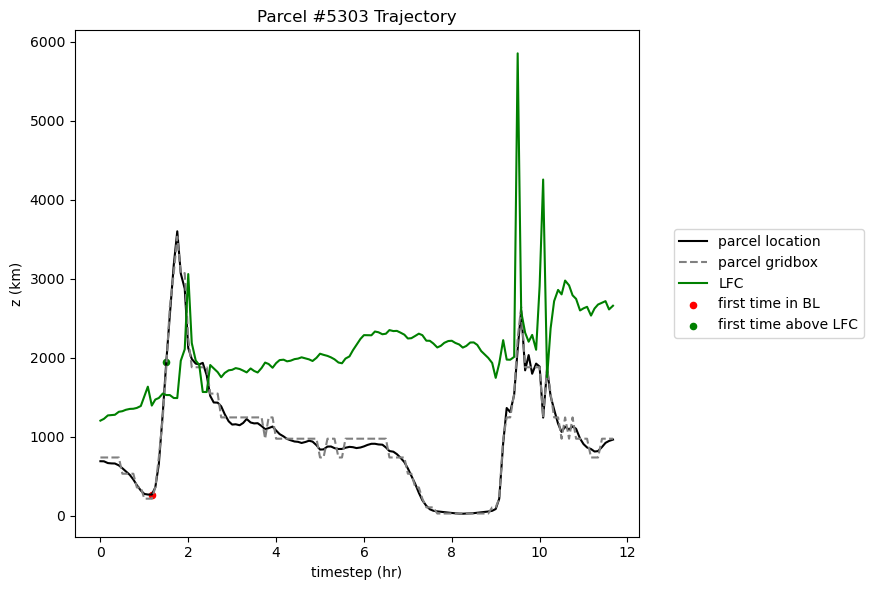

In [61]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

# Assuming 'data', 'ALL_out_arr', 'parcel', 'LFC_data', 'Z', 'T', 'Y', 'X', etc., are already defined

# Define grid for the plot and legend
fig = plt.figure(figsize=(10, 6))
gs = gridspec.GridSpec(1, 2, width_ratios=[0.85, 0.15])  # 1 row, 2 columns, second column is smaller for legend

# Define the first subplot for the trajectory plot
ax1 = plt.subplot(gs[0])

# Define time steps and other data
tsteps = np.arange(len(data['time'])) * 5 / 60
tsteps = np.round(tsteps, 2)

i = 40
p = out_arr[i, 0]
t1 = out_arr[i, 1]
t2 = out_arr[i, 2]

z1 = parcel['z'][t1, p]
z2 = parcel['z'][t2, p]

zs = parcel['z'][:, p]
zgrids = data['zh'][Z[:, p]] * 1000

lfcs = LFC_data[T[:, p], Y[:, p], X[:, p]]

# Plot parcel trajectory, grid, and LFC
ax1.plot(tsteps, zs, color='black', label='parcel location')
ax1.plot(tsteps, zgrids, linestyle='dashed', color='grey', label='parcel gridbox')
ax1.plot(tsteps, lfcs, color='green', label='LFC')
ax1.scatter(t1 * 5 / 60, z1, color='red', s=20, label='first time in BL')
ax1.scatter(t2 * 5 / 60, z2, color='green', s=20, label='first time above LFC')

# Labels and title
ax1.set_xlabel('timestep (hr)')
ax1.set_ylabel('z (km)')
ax1.set_title(f'Parcel #{p} Trajectory')

# Set up legend in the second subplot (outside of the plot)
# Adjusting bbox_to_anchor to move legend outside
ax1.legend(bbox_to_anchor=(1.05, 0.5), loc='center left', fontsize=10)

# Adjust layout to prevent overlap
fig.tight_layout()

# Show the plot
plt.show()
